In [26]:
#%%Simulation to obtain number-splitting
import matplotlib.pyplot as plt
import numpy as np
from qutip import *
from scipy.optimize import minimize
import h5py
import scipy as sc
import time
import math

In [27]:
# start_time = time.time()#checking how long the code takes

# erf = sc.special.erf #error function constant

# qdim = 2
# q = destroy(qdim)
# qd = create(qdim)

# chi = 2.5e-3#in GHzQ
# alpha = 1.78
# cdim = 10

# T1 = np.inf#32e3#in ns
# T2 = np.inf#4.2e3#in ns
# Tphi = np.inf#- 1/(1/2/T1 - 1/T2)
# cavT1 = np.inf#1.2e6#in ns
# # T1 = 84e3#in ns
# # T2 = 21e3#in ns
# # Tphi = - 1/(1/2/T1 - 1/T2)
# # cavT1 = 1.21e6#in ns
# nbar_cav = 0#0.3656#thermal state

# # Contains information about the (pulse amplitude, pulse sigma, pulse chop)
# calibration = [
#     (1, 800, 4),#tuple
# ]

# A, sigma, chop = calibration[0]

# matrix_elements = None
# peak_heights = None
# num_split_plot = None
# freq_detune = np.linspace(-20,10, 201) * 1e-3# in GHz

# if 1:
#     '''
#     Power Rabi: Use this to calibrate the amplitude needed to drive a qubit pi pulse
#     '''
#     amp = np.linspace(0, 1.5, 199)
#     output = []

#     for Ax in amp:
#         A = np.sqrt(2/np.pi) / erf(np.sqrt(2))*np.pi/(4*sigma)/2/np.pi#initial guess
#         A0 = A#keep it for later

#         frq = 0#resonant driving

#         A *= Ax#coefficient for the Gaussian pulse

#         H0 = 2*np.pi*frq * qd*q
#         Hd = 2*np.pi*A*1j*(qd - q)#or with other part Hd = 2*np.pi*A*(qd + q)

#         def pulse(t, *arg):
#             global sigma, chop
#             t0 = sigma*chop/2

#             g = np.exp( - 1/2 * (t - t0)**2 / sigma**2)

#             return g

#         H = [H0, [Hd, pulse]]

#         psi = basis(qdim, 0)#initial state
#         rhoq = ket2dm(psi)

#         tlist = np.linspace(0, sigma*chop, 100)

#         c_ops = [
#             np.sqrt(1/T1)*q,
#             np.sqrt(2/Tphi)*qd*q#changed
#         ]

#         e_ops = [qd*q,]

#         options = Options(max_step = 1, nsteps = 1e6)

#         results = mesolve(H, rhoq, tlist, c_ops= c_ops, e_ops = e_ops)#, options= options)#, progress_bar = True)

#         output += [results.expect[0][-1],]
    
#     plt.plot(amp, output)
#     plt.ylabel(r"pe")
#     plt.xlabel("Amplitude Scale")
#     plt.title("Power Rabi")
#     plt.grid()
#     plt.show()

#     print(max(output), output.index(max(output)), amp[output.index(max(output))])
#     A = A0*amp[output.index(max(output))]#this is the correct coeff
    
# if 1:
#     '''
#     Number Splitting simulation
#     '''

#     Q = tensor(destroy(qdim), qeye(cdim))
#     C = tensor(qeye(qdim), destroy(cdim))

#     Cd, Qd = C.dag(), Q.dag()

#     output = []

#     for frq in freq_detune:
#         H0 = -2*np.pi*frq * Qd*Q - 2*np.pi*chi*Qd*Q*Cd*C
#         Hd = 2*np.pi*1j*(Qd - Q)

#         def pulse(t, *arg):
#             t0 = sigma*chop/2
#             g = A*np.exp( - 1/2 * (t - t0)**2 / sigma**2)

#             return g

#         H = [H0, [Hd, pulse]]

#         # Initialise a thermal state
#         psi = tensor(basis(qdim,0), coherent(cdim,alpha))
#         rho = ket2dm(psi)

#         # Displace the state
#         # psi = tensor(qeye(2),displace(cdim, 1),) * psi * tensor(qeye(2),displace(cdim, -1),)

#         tlist = np.linspace(0, sigma*chop, 101)

#         c_ops = [
#             # Qubit Relaxation
#             np.sqrt(1/T1)*Q,
#             # Qubit Dephasing, changed
#             np.sqrt(2/Tphi)*Qd*Q,
#             # Cavity Relaxation
#             np.sqrt((1 + nbar_cav)/cavT1) * C,
#             # Cavity Thermal Excitations
#             np.sqrt(nbar_cav/cavT1) * Cd,
#         ]

#         e_ops = [Qd*Q,]

#         # options = Options(max_step = 4, nsteps = 1e6)
#         results = mesolve(H, rho, tlist, c_ops= c_ops, e_ops = e_ops)#, options = options)#, progress_bar = True)

#         output += [results.expect[0][-1],]
#     fig = plt.figure(figsize = (8,5))
#     plt.plot((freq_detune)*1e3, output,)

#     # plt.legend()
#     plt.ylabel(f"pe")
#     plt.xlabel("Detuning (MHz)")
#     plt.title("PNS simulation")
#     plt.grid()
#     plt.show()

# print("")
# print("--- %s seconds ---" % (time.time() - start_time))


In [28]:
# full_path = r"D:\Users\candace\number_splitting\15-23-27_NumberSplittinghdf5_Processed_NumberSplitting.npz"
# data = np.load(full_path)

# amp = data['amp']
# qubit_frequency = data['qubit_frequency']
# mag = data['mag']
# I = data['I']
# Q = data['Q']

# # 3. Use the data
# print(f"Loaded magnitude shape: {mag.shape}")

# plt.plot((qubit_frequency+50e6)/1e6, mag[:,1])
# plt.show()

In [29]:
# mag_1 = mag[:,1]
# # mag_1 -= np.mean(mag_1)
# # mag_1 /= np.std(mag_1)

# sim_peak = np.max(output)
# sim_min = np.min(output)
# meas_peak = np.max(mag_1)
# meas_min = np.min(mag_1)
# mag_1_scaled = (mag_1 - meas_min) / (meas_peak - meas_min) * (sim_peak - sim_min) + sim_min

# fig = plt.figure(figsize = (8,5))
# plt.plot((freq_detune)*1e3, output,)
# plt.plot((qubit_frequency+50e6)/1e6, mag_1_scaled)

# # plt.legend()
# plt.ylabel(f"pe")
# plt.xlabel("Detuning (MHz)")
# plt.title("PNS simulation")
# plt.grid()
# plt.show()

In [30]:
erf = sc.special.erf #error function constant

qdim = 2
q = destroy(qdim)
qd = create(qdim)
T1 = np.inf#32e3#in ns
T2 = np.inf#4.2e3#in ns
Tphi = np.inf#- 1/(1/2/T1 - 1/T2)
cavT1 = np.inf#1.2e6#in ns
nbar_cav = 0#0.3656#thermal state

# Contains information about the (pulse amplitude, pulse sigma, pulse chop)
calibration = [
    (1, 800, 4),#tuple
]

A, sigma, chop = calibration[0]
matrix_elements = None
peak_heights = None
num_split_plot = None

In [31]:
def number_split_sim(cdim, chi, alpha, freq_detune):
    amp = np.linspace(0, 1.5, 199)
    output = []

    for Ax in amp:
        A = np.sqrt(2/np.pi) / erf(np.sqrt(2))*np.pi/(4*sigma)/2/np.pi#initial guess
        A0 = A#keep it for later

        frq = 0#resonant driving

        A *= Ax#coefficient for the Gaussian pulse

        H0 = 2*np.pi*frq * qd*q
        Hd = 2*np.pi*A*1j*(qd - q)#or with other part Hd = 2*np.pi*A*(qd + q)

        def pulse(t, *arg):
            global sigma, chop
            t0 = sigma*chop/2

            g = np.exp( - 1/2 * (t - t0)**2 / sigma**2)

            return g

        H = [H0, [Hd, pulse]]

        psi = basis(qdim, 0)#initial state
        rhoq = ket2dm(psi)

        tlist = np.linspace(0, sigma*chop, 100)

        c_ops = [
            np.sqrt(1/T1)*q,
            np.sqrt(2/Tphi)*qd*q#changed
        ]

        e_ops = [qd*q,]

        options = Options(max_step = 1, nsteps = 1e6)

        results = mesolve(H, rhoq, tlist, c_ops= c_ops, e_ops = e_ops)#, options= options)#, progress_bar = True)

        output += [results.expect[0][-1],]

    A = A0*amp[output.index(max(output))]#this is the correct coeff

    '''
    Number Splitting simulation
    '''

    A = np.sqrt(2/np.pi) / erf(np.sqrt(2))*np.pi/(4*sigma)/2/np.pi#initial guess


    Q = tensor(destroy(qdim), qeye(cdim))
    C = tensor(qeye(qdim), destroy(cdim))

    Cd, Qd = C.dag(), Q.dag()

    output = []

    for frq in freq_detune:
        H0 = -2*np.pi*frq * Qd*Q - 2*np.pi*chi*Qd*Q*Cd*C
        Hd = 2*np.pi*1j*(Qd - Q)

        def pulse(t, *arg):
            t0 = sigma*chop/2
            g = A*np.exp( - 1/2 * (t - t0)**2 / sigma**2)

            return g

        H = [H0, [Hd, pulse]]

        # Initialise a thermal state
        psi = tensor(basis(qdim,0), coherent(cdim,alpha))
        rho = ket2dm(psi)

        # Displace the state
        # psi = tensor(qeye(2),displace(cdim, 1),) * psi * tensor(qeye(2),displace(cdim, -1),)

        tlist = np.linspace(0, sigma*chop, 101)

        c_ops = [
            # Qubit Relaxation
            np.sqrt(1/T1)*Q,
            # Qubit Dephasing, changed
            np.sqrt(2/Tphi)*Qd*Q,
            # Cavity Relaxation
            np.sqrt((1 + nbar_cav)/cavT1) * C,
            # Cavity Thermal Excitations
            np.sqrt(nbar_cav/cavT1) * Cd,
        ]

        e_ops = [Qd*Q,]

        # options = Options(max_step = 4, nsteps = 1e6)
        results = mesolve(H, rho, tlist, c_ops= c_ops, e_ops = e_ops)#, options = options)#, progress_bar = True)

        output += [results.expect[0][-1],]

    return output

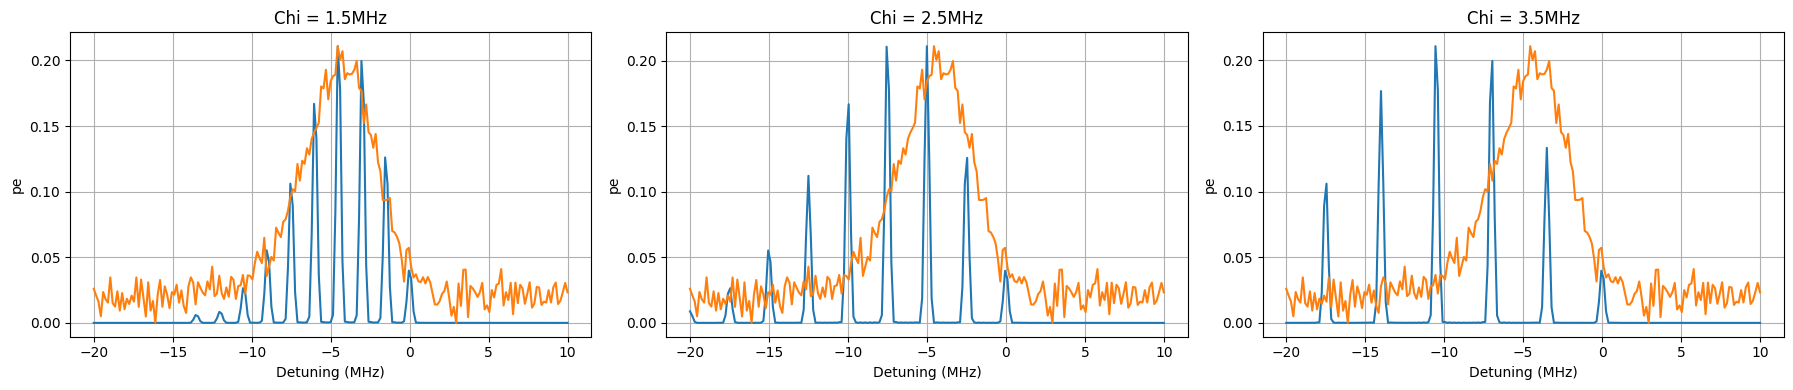

In [34]:
# chi_list = np.linspace(2.5, 3, 1)*1e-3

chi_list = np.array([1.5, 2.5, 3.5])*1e-3
alpha = 1.78
cdim = 10
freq_detune = np.linspace(-20,10, 201) * 1e-3# in GHz

full_path = r"D:\Users\candace\number_splitting\15-23-27_NumberSplittinghdf5_Processed_NumberSplitting.npz"
data = np.load(full_path)

amp = data['amp']
qubit_frequency = data['qubit_frequency']
mag = data['mag']
I = data['I']
Q = data['Q']

mag_1 = mag[:,1]
meas_peak = np.max(mag_1)
meas_min = np.min(mag_1)

# # 3. Use the data
# print(f"Loaded magnitude shape: {mag.shape}")

# plt.plot((qubit_frequency+50e6)/1e6, mag[:,1])
# plt.show()

nplots = len(chi_list)
ncols = 4
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6*ncols, 4*nrows),
    squeeze=False
)

axes = axes.flatten()
i=0
for chi in chi_list:
    try:
        sim_result = number_split_sim(cdim, chi, alpha, freq_detune)
        sim_peak = np.max(sim_result)
        sim_min = np.min(sim_result)
        mag_1_scaled = (mag_1 - meas_min) / (meas_peak - meas_min) * (sim_peak - sim_min) + sim_min
        ax = axes[i]
        i+=1
        ax.plot(freq_detune * 1e3, sim_result)
        ax.plot((qubit_frequency+50e6)/1e6, mag_1_scaled)
        ax.set_title(f"Chi = {chi/1e-3}MHz")
        ax.set_ylabel("pe")
        ax.set_xlabel("Detuning (MHz)")
        ax.grid(True)
    except:
        print(f"Invalid result from {chi/1e-3}MHz")

for j in range(nplots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Invalid result from 3.5MHz


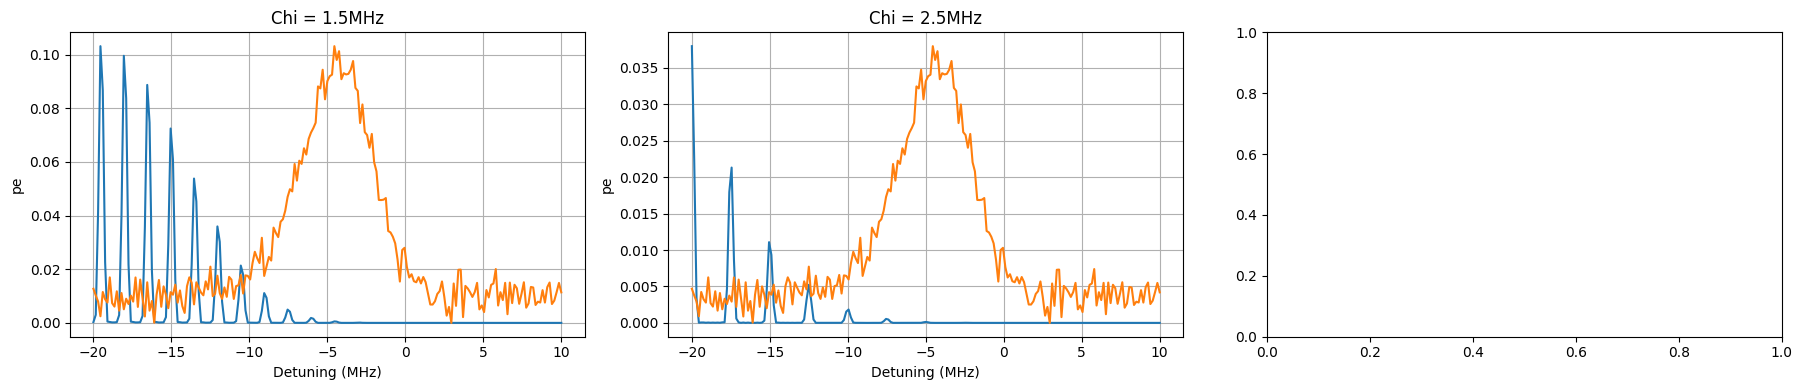

In [ ]:
# chi_list = np.linspace(2.5, 3, 1)*1e-3

chi_list = np.array([1.5])*1e-3
alpha = 3.67
cdim = 25
freq_detune = np.linspace(-20,10, 201) * 1e-3# in GHz

full_path = r"D:\Users\candace\number_splitting\15-23-27_NumberSplittinghdf5_Processed_NumberSplitting.npz"
data = np.load(full_path)

amp = data['amp']
qubit_frequency = data['qubit_frequency']
mag = data['mag']
I = data['I']
Q = data['Q']

mag_2 = mag[:,2]
meas_peak = np.max(mag_2)
meas_min = np.min(mag_2)

# # 3. Use the data
# print(f"Loaded magnitude shape: {mag.shape}")

# plt.plot((qubit_frequency+50e6)/1e6, mag[:,1])
# plt.show()

nplots = len(chi_list)
ncols = 4
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6*ncols, 4*nrows),
    squeeze=False
)

axes = axes.flatten()
i=0
for chi in chi_list:
    try:
        sim_result = number_split_sim(cdim, chi, alpha, freq_detune)
        sim_peak = np.max(sim_result)
        sim_min = np.min(sim_result)
        mag_2_scaled = (mag_2 - meas_min) / (meas_peak - meas_min) * (sim_peak - sim_min) + sim_min
        ax = axes[i]
        i+=1
        ax.plot(freq_detune * 1e3, sim_result)
        ax.plot((qubit_frequency+50e6)/1e6, mag_2_scaled)
        ax.set_title(f"Chi = {chi/1e-3}MHz")
        ax.set_ylabel("pe")
        ax.set_xlabel("Detuning (MHz)")
        ax.grid(True)
    except:
        print(f"Invalid result from {chi/1e-3}MHz")

for j in range(nplots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()